# Toeplitz & Final-Key Fault Validation

Tests the PA-stage fault models (Toeplitz-matrix corruption, final-key corruption) against
real-channel data, in both `asymptotic` and `finite_key` length modes. These are the two
fault types whose goodness-of-fit came back clean (p≈1.0) — this notebook is where that
result lives, with three progressively more rigorous checks: idealized-leakage prediction,
fitted-leakage prediction, and the length mode that actually matches how the data was
collected.

Run `20_data_cleaning_and_integrity.ipynb` first — this loads its cleaned output.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))

from qne.cascade.finite_key import h, v, finite_key_output_length, optimize_nu
from qne.cascade.validation_utils import wilson_ci, chi_square_goodness_of_fit, report_fit

RESULTS = PROJECT_DIR / "results"
key_pairs_df = pd.read_csv(str(RESULTS / "key_pairs_metadata.csv"))
toeplitz_clean = pd.read_csv(str(RESULTS / "toeplitz_clean.csv"))
final_key_clean = pd.read_csv(str(RESULTS / "final_key_clean.csv"))
toeplitz_fk_clean = pd.read_csv(str(RESULTS / "toeplitz_fk_clean.csv"))
final_key_fk_clean = pd.read_csv(str(RESULTS / "final_key_fk_clean.csv"))
print("Loaded cleaned data")


Loaded cleaned data


## Candidate output-length formulas

Three ways to compute `ell` (the secure output length), from least to most rigorous. Only
`ell_asymptotic_actual` and `ell_finite_key_actual` actually match what was used to collect
data (the other two are exploratory "what if" variants) — keep that distinction explicit
rather than treating all four as equally valid predictions.

In [2]:
def asymptotic_key_length(n_bits, Q):
    return max(0, int(n_bits * (1 - 2 * h(Q))))

def verification_t(eps_ec=1e-10):
    return max(1, int(np.ceil(-np.log2(eps_ec))))

def ell_asymptotic_actual(n, k_pe, Q, eps=1e-10):
    """Matches --length-mode asymptotic exactly, as actually collected."""
    t = verification_t(eps)
    return asymptotic_key_length(n, Q), t

def ell_finite_key_actual(n, k_pe, Q):
    """Matches --length-mode finite_key exactly, as actually collected."""
    ell, r, t, nu = finite_key_output_length(n, k_pe, Q)
    return max(0, int(round(ell))), int(max(1, round(t)))

def ell_idealized(n, k_pe, Q, eps=1e-10, eps_pa=1e-10):
    """Exploratory: Corollary-2 bound with no fitted leakage correction."""
    cbar = 0.5
    t = verification_t(eps)
    nu, _, r_idealized, _ = optimize_nu(n, k_pe, Q, eps_ec=eps, eps_pa=eps_pa, c_bar=cbar)
    ell = n * (np.log2(1 / cbar) - h(Q + nu)) - r_idealized - t - 2 * np.log2(1 / (2 * eps_pa))
    return max(0, ell), t

def ell_fitted(n, k_pe, Q, xi1_hat=2.35, eps=1e-10, eps_pa=1e-10):
    """Exploratory: fitted xi1 leakage, nu re-optimized against it."""
    cbar = 0.5
    t = verification_t(eps)
    r_fitted = xi1_hat * n * h(Q)
    nu, _, r_used, _ = optimize_nu(n, k_pe, Q, eps_ec=eps, eps_pa=eps_pa, c_bar=cbar, r_override=r_fitted)
    ell = n * (np.log2(1 / cbar) - h(Q + nu)) - r_used - t - 2 * np.log2(1 / (2 * eps_pa))
    return max(0, ell), t


## Per-key validation prints

In [3]:
def validate_toeplitz(df_clean, key_pairs_df, ell_func, p1, label):
    print(f"=== Toeplitz validation: {label} ===")
    for key_idx in sorted(df_clean["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
        ell, t_verify = ell_func(n_bits, k_pe, Q)
        sub = df_clean[df_clean["key_index"] == key_idx]
        for prob in sorted(sub["prob"].unique()):
            trials = sub[sub["prob"] == prob]
            successes = trials["mismatch"].sum()
            p_hat, lo, hi = wilson_ci(successes, len(trials))
            predicted = prob * (ell / (ell + t_verify)) * p1
            in_ci = lo <= predicted <= hi
            print(f"  key{key_idx} q={prob:<6}: observed={p_hat:.3f}[{lo:.3f},{hi:.3f}] "
                  f"predicted={predicted:.3f} (ell={ell:.0f}, t={t_verify}) {'OK' if in_ci else 'OUTSIDE'}")

def validate_final_key(df_clean, key_pairs_df, ell_func, label):
    print(f"=== Final-key validation: {label} ===")
    for key_idx in sorted(df_clean["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
        ell, t_verify = ell_func(n_bits, k_pe, Q)
        sub = df_clean[df_clean["key_index"] == key_idx]
        for prob in sorted(sub["prob"].unique()):
            trials = sub[sub["prob"] == prob]
            successes = trials["mismatch"].sum()
            p_hat, lo, hi = wilson_ci(successes, len(trials))
            predicted = prob * (ell / (ell + t_verify))
            in_ci = lo <= predicted <= hi
            print(f"  key{key_idx} q={prob:<6}: observed={p_hat:.3f}[{lo:.3f},{hi:.3f}] "
                  f"predicted={predicted:.3f} (ell={ell:.0f}, t={t_verify}) {'OK' if in_ci else 'OUTSIDE'}")

validate_toeplitz(toeplitz_clean, key_pairs_df, ell_asymptotic_actual, p1=0.5, label="asymptotic (matches collection)")
print()
validate_final_key(final_key_clean, key_pairs_df, ell_asymptotic_actual, label="asymptotic (matches collection)")


=== Toeplitz validation: asymptotic (matches collection) ===
  key0 q=0.001 : observed=0.000[0.000,0.278] predicted=0.000 (ell=2810, t=34) OK
  key0 q=0.003 : observed=0.000[0.000,0.278] predicted=0.001 (ell=2810, t=34) OK
  key0 q=0.01  : observed=0.000[0.000,0.278] predicted=0.005 (ell=2810, t=34) OK
  key0 q=0.03  : observed=0.000[0.000,0.278] predicted=0.015 (ell=2810, t=34) OK
  key0 q=0.05  : observed=0.000[0.000,0.278] predicted=0.025 (ell=2810, t=34) OK
  key0 q=0.1   : observed=0.000[0.000,0.278] predicted=0.049 (ell=2810, t=34) OK
  key0 q=0.3   : observed=0.200[0.057,0.510] predicted=0.148 (ell=2810, t=34) OK
  key0 q=0.5   : observed=0.200[0.057,0.510] predicted=0.247 (ell=2810, t=34) OK
  key1 q=0.001 : observed=0.000[0.000,0.278] predicted=0.000 (ell=2608, t=34) OK
  key1 q=0.003 : observed=0.000[0.000,0.278] predicted=0.001 (ell=2608, t=34) OK
  key1 q=0.01  : observed=0.000[0.000,0.278] predicted=0.005 (ell=2608, t=34) OK
  key1 q=0.03  : observed=0.000[0.000,0.278] pre

## Chi-square goodness of fit — the headline numbers

In [4]:
def make_predictor(ell_func, p1):
    def predictor(krow, prob):
        n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
        ell, t_verify = ell_func(n_bits, k_pe, Q)
        return prob * (ell / (ell + t_verify)) * (p1 if p1 else 1.0)
    return predictor

chi2_s, dof, p = chi_square_goodness_of_fit(toeplitz_clean, key_pairs_df, make_predictor(ell_asymptotic_actual, 0.5))
report_fit("Toeplitz, asymptotic mode", chi2_s, dof, p)

chi2_s, dof, p = chi_square_goodness_of_fit(final_key_clean, key_pairs_df, make_predictor(ell_asymptotic_actual, None))
report_fit("Final-key, asymptotic mode", chi2_s, dof, p)

chi2_s, dof, p = chi_square_goodness_of_fit(toeplitz_fk_clean, key_pairs_df, make_predictor(ell_finite_key_actual, 0.5))
report_fit("Toeplitz, finite_key mode", chi2_s, dof, p)

chi2_s, dof, p = chi_square_goodness_of_fit(final_key_fk_clean, key_pairs_df, make_predictor(ell_finite_key_actual, None))
report_fit("Final-key, finite_key mode", chi2_s, dof, p)


Toeplitz, asymptotic mode: chi2=30.03, dof=40, p=0.8744 -- NOT rejected (good fit)
Final-key, asymptotic mode: chi2=15.44, dof=40, p=0.9998 -- NOT rejected (good fit)
Toeplitz, finite_key mode: chi2=10.58, dof=40, p=1.0000 -- NOT rejected (good fit)
Final-key, finite_key mode: chi2=10.70, dof=40, p=1.0000 -- NOT rejected (good fit)


## Plots: pooled and per-key

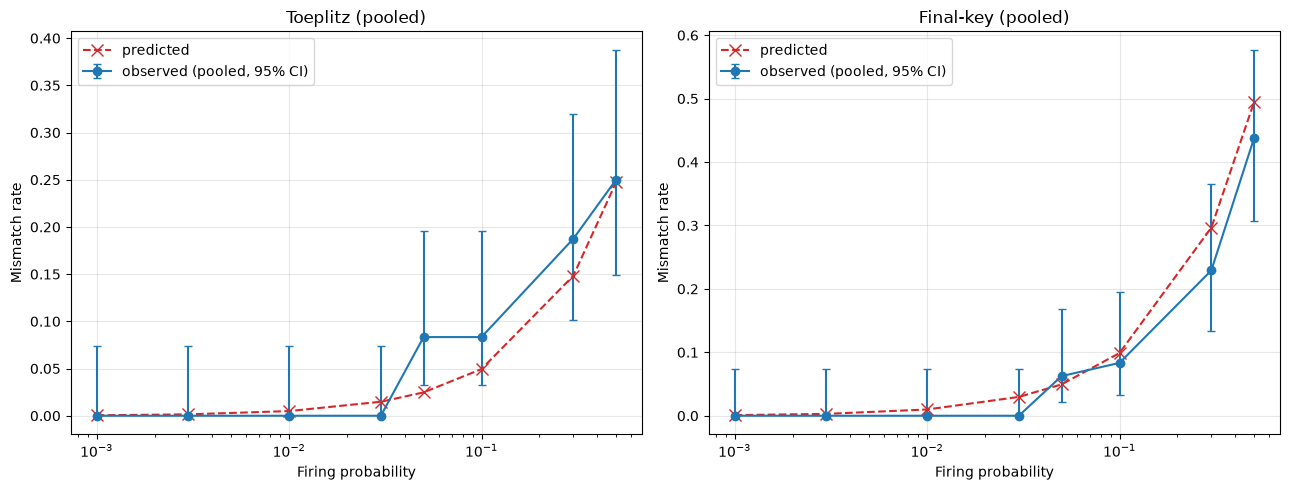

In [5]:
def plot_pooled_validation(df_clean, key_pairs_df, ell_func, p1, label, ax, prob_col="prob"):
    probs = sorted(df_clean[prob_col].unique())
    pooled_obs, pooled_lo, pooled_hi, mean_pred = [], [], [], []
    for prob in probs:
        sub = df_clean[df_clean[prob_col] == prob]
        p_hat, lo, hi = wilson_ci(sub["mismatch"].sum(), len(sub))
        pooled_obs.append(p_hat); pooled_lo.append(lo); pooled_hi.append(hi)
        key_preds = []
        for key_idx in sub["key_index"].unique():
            krow = key_pairs_df.iloc[key_idx]
            n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
            ell, t_verify = ell_func(n_bits, k_pe, Q)
            key_preds.append(prob * (ell / (ell + t_verify)) * (p1 if p1 else 1.0))
        mean_pred.append(np.mean(key_preds))
    pooled_obs, pooled_lo, pooled_hi = np.array(pooled_obs), np.array(pooled_lo), np.array(pooled_hi)
    ax.errorbar(probs, pooled_obs, yerr=[np.clip(pooled_obs - pooled_lo, 0, None),
                                            np.clip(pooled_hi - pooled_obs, 0, None)],
                  fmt="o-", capsize=3, label="observed (pooled, 95% CI)")
    ax.plot(probs, mean_pred, "x--", color="tab:red", label="predicted", markersize=9)
    ax.set_xscale("log"); ax.set_xlabel("Firing probability"); ax.set_ylabel("Mismatch rate")
    ax.set_title(label); ax.legend(); ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pooled_validation(toeplitz_clean, key_pairs_df, ell_asymptotic_actual, p1=0.5, label="Toeplitz (pooled)", ax=axes[0])
plot_pooled_validation(final_key_clean, key_pairs_df, ell_asymptotic_actual, p1=None, label="Final-key (pooled)", ax=axes[1])
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_toeplitz_finalkey_pooled.png"), dpi=150)
plt.show()
